In [54]:
import pandas as pd
data = pd.read_csv('google_max_30.csv')

# Affichage des premières lignes pour avoir un aperçu
data.head()


,Rating,Reviews,Size,Installs,Price,Timestamp,Category_BOOKS_AND_REFERENCE,Category_BUSINESS,Category_COMMUNICATION,Category_DATING,...,Genres_Puzzle,Genres_Role Playing,Genres_Shopping,Genres_Simulation,Genres_Social,Genres_Sports,Genres_Tools,Genres_Travel & Local,Genres_Video Players & Editors,Genres_infrequent_sklearn
0,4.1,159.0,19000000.0,4.00000,0.0,1.515283e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,3.9,967.0,14000000.0,5.69897,0.0,1.515974e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,4.7,87510.0,8700000.0,6.69897,0.0,1.533082e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,4.5,215644.0,25000000.0,7.69897,0.0,1.528416e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4.3,967.0,2800000.0,5.00000,0.0,1.529453e+09,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [43]:
# Calcul des statistiques descriptives pour les variables numériques
descriptive_stats = data.describe()

# Calcul de la corrélation entre les variables, en se concentrant sur la colonne 'Rating'
correlation_with_rating = data.corr()['Rating'].sort_values(ascending=False)

descriptive_stats, correlation_with_rating


(            Rating       Reviews          Size     Installs        Price  \
 count  7723.000000  7.723000e+03  7.723000e+03  7723.000000  7723.000000   
 mean      4.173935  2.948983e+05  2.297046e+07     5.059810     1.128169   
 std       0.544638  1.863933e+06  2.344963e+07     1.608296    17.408036   
 min       1.000000  1.000000e+00  8.500000e+03     0.000000     0.000000   
 25%       4.000000  1.075000e+02  5.300000e+06     4.000000     0.000000   
 50%       4.300000  2.332000e+03  1.400000e+07     5.000000     0.000000   
 75%       4.500000  3.905300e+04  3.300000e+07     6.000000     0.000000   
 max       5.000000  4.489389e+07  1.000000e+08     9.000000   400.000000   
 
           Timestamp  Category_BOOKS_AND_REFERENCE  Category_BUSINESS  \
 count  7.723000e+03                   7723.000000        7723.000000   
 mean   1.509190e+09                      0.018646           0.031853   
 std    3.595212e+07                      0.135279           0.175620   
 min    1.274

Des colonnes de catégories (Category_XXX) et de genres (Genres_XXX), qui semblent être des variables binaires indiquant l'appartenance à une catégorie ou à un genre.

## Statistiques Descriptives
Rating: La moyenne est d'environ 4.17, avec un écart-type de 0.54, indiquant une variabilité modérée dans les notes.
Reviews: Il y a une grande variété dans le nombre de critiques, avec une moyenne élevée due à quelques applications ayant un très grand nombre de critiques.
Size et Installs: Ces variables ont également une large gamme de valeurs.
Price: La plupart des applications semblent être gratuites, mais il y a quelques exceptions avec des prix élevés.
## Corrélation avec la Note
Timestamp (date de dernière mise à jour ou création) a la corrélation la plus élevée avec la note, mais la corrélation est toujours modeste (0.13).
Les variables Installs, Size, et Reviews montrent également des corrélations positives mais faibles avec la note.
Certaines catégories et genres ont des corrélations négatives modestes avec la note, comme Category_TOOLS et Genres_Tools.

In [44]:
plt.rcParams['figure.figsize'] = (15, 7)  # Taille par défaut de la figure
plt.rcParams['axes.titlesize']=18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['legend.fontsize']=10
plt.rcParams['legend.title_fontsize'] = 12

# ACP
##
En excluant la variable Rating, effectuer une ACP sur les variables restantes. Tracer le courbe cumulative de la variance expliquée

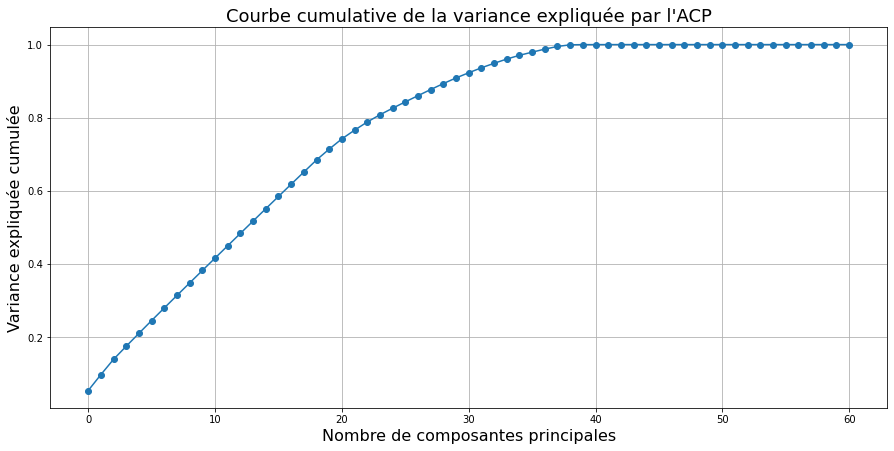

array([0.0542659 , 0.09787274, 0.13966441, 0.17546951, 0.21068439,
       0.24563161, 0.28009447, 0.31432876, 0.34843159, 0.38241701,
       0.41629668, 0.4501121 , 0.48388628, 0.51761017, 0.55126723,
       0.58478142, 0.6182285 , 0.65149539, 0.68459573, 0.7142109 ,
       0.74223278, 0.76601848, 0.78836915, 0.80809098, 0.82600726,
       0.8433852 , 0.86033627, 0.87702751, 0.89336057, 0.9088054 ,
       0.92293544, 0.93655325, 0.94875885, 0.96043192, 0.97067021,
       0.97921861, 0.98761235, 0.99482266, 0.99936693, 0.99983798,
       0.99991279, 0.99996756, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        ])

In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Exclusion de la colonne 'Rating'
data_acp = data.drop('Rating', axis=1)

# Normalisation des données
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_acp)

# Application de l'ACP
pca_df = PCA()
pca_df.fit(data_scaled)

# Calcul de la variance expliquée cumulée
variance_cumulative = pca_df.explained_variance_ratio_.cumsum()

# Tracé de la courbe cumulative de la variance expliquée
plt.plot(variance_cumulative, marker='o')
plt.xlabel('Nombre de composantes principales')
plt.ylabel('Variance expliquée cumulée')
plt.title('Courbe cumulative de la variance expliquée par l\'ACP')
plt.grid(True)
plt.show()

variance_cumulative


<Figure size 1440x720 with 0 Axes>

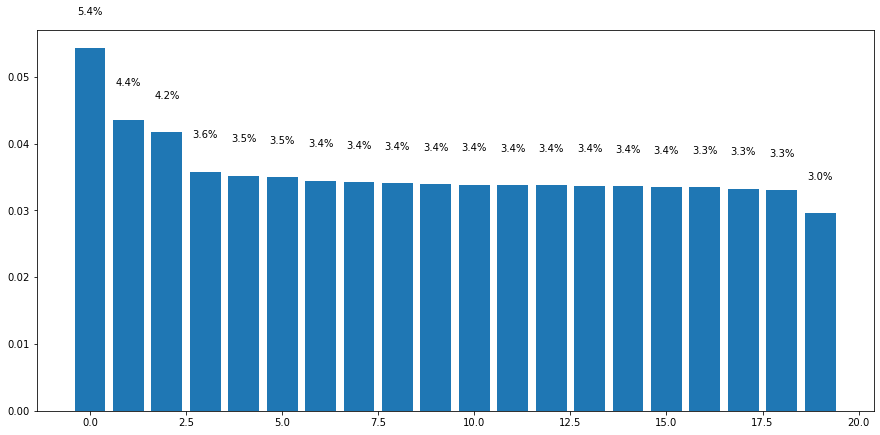

<Figure size 1440x720 with 0 Axes>

In [46]:
#Pour vérifier c'est une bonne interprétation ou pas.
plt.bar(range(20), pca_df.explained_variance_ratio_[:20])
for i, var in enumerate(pca_df.explained_variance_ratio_[:20]):
    plt.text(i, var + 0.005,f'{var:.1%}', ha='center',size='10')
plt.figure(figsize=(20, 10))

### COMMENTAIRE:
Les premières composantes principales ne capturent qu'une petite partie de la variance totale. Par exemple, la première composante principale explique environ 5.4% de la variance, tandis que les deux premières ensemble en expliquent environ 9.8%.
Même en augmentant le nombre de composantes, la variance expliquée augmente lentement. Il faut un grand nombre de composantes pour capturer une proportion significative de la variance totale.

Cette observation suggère que les données sont assez complexes et qu'elles ne sont pas bien représentées dans un espace à faible dimensionnalité. Cela peut être dû à la présence de nombreuses variables peu corrélées entre elles ou à une structure inhérente complexe des données.

##
Nuage des individus projétés sur les 2 premières composantes principales, colorés par rating.\
Cette visualisation nous aidera à comprendre si ces deux composantes peuvent être utiles pour prédire le "Rating" des applications. Si les applications avec des notes similaires sont regroupées ensemble dans le plan formé par les deux premières composantes principales, cela indiquerait que ces composantes capturent des informations pertinentes à la note. Sinon, cela suggérerait que d'autres dimensions ou une approche analytique différente pourraient être nécessaires.

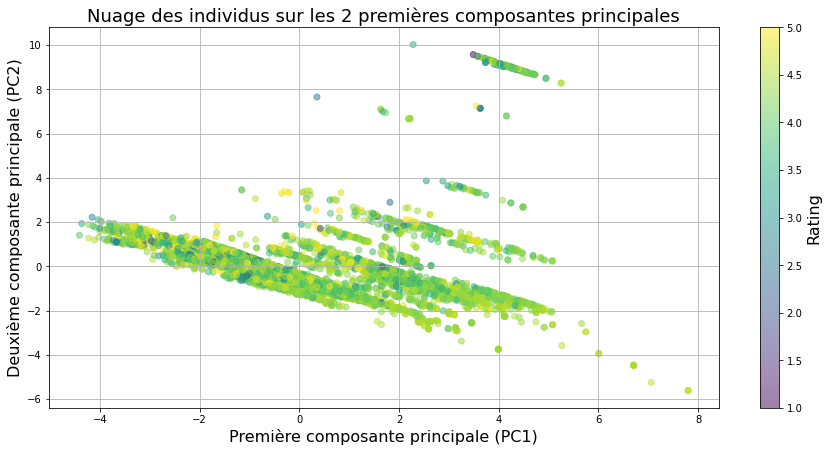

In [47]:
pca_2d = PCA(n_components=2)
data_2d = pca_2d.fit_transform(data_scaled)

# Préparation des données pour le graphique
df_2d = pd.DataFrame(data_2d, columns=['PC1', 'PC2'])
df_2d['Rating'] = data['Rating']

# Création du graphique
scatter = plt.scatter(df_2d['PC1'], df_2d['PC2'], c=df_2d['Rating'], cmap='viridis', alpha=0.5)
plt.title('Nuage des individus sur les 2 premières composantes principales')
plt.xlabel('Première composante principale (PC1)')
plt.ylabel('Deuxième composante principale (PC2)')
plt.colorbar(scatter, label='Rating')
plt.grid(True)
plt.show()

En examinant le graphique, il semble que les points sont assez dispersés et qu'il n'y a pas de regroupements clairs ou de motifs distincts basés sur le "Rating". Les différentes notes semblent être distribuées de manière relativement homogène à travers les deux composantes principales. Cela suggère que les deux premières composantes de l'ACP ne capturent pas suffisamment d'informations pour distinguer clairement les applications en fonction de leur note.

Cette observation indique qu'il serait probablement difficile d'obtenir une bonne prédiction de la note des applications en utilisant uniquement ces deux composantes. Les données sont complexes et multidimensionnelles, et il semble que d'autres caractéristiques ou composantes supplémentaires sont nécessaires pour capturer les facteurs qui influencent la note des applications.


##
Même nuage, colorés selon la qualité de la représentation (cosinus carré).\
Pour visualiser le nuage des individus en colorant chaque point selon la qualité de sa représentation (mesurée par le cosinus carré sur les deux premières composantes principales), nous devons calculer cette métrique pour chaque individu. Le cosinus carré indique la proportion de la variance de chaque individu qui est expliquée par les composantes principales choisies.

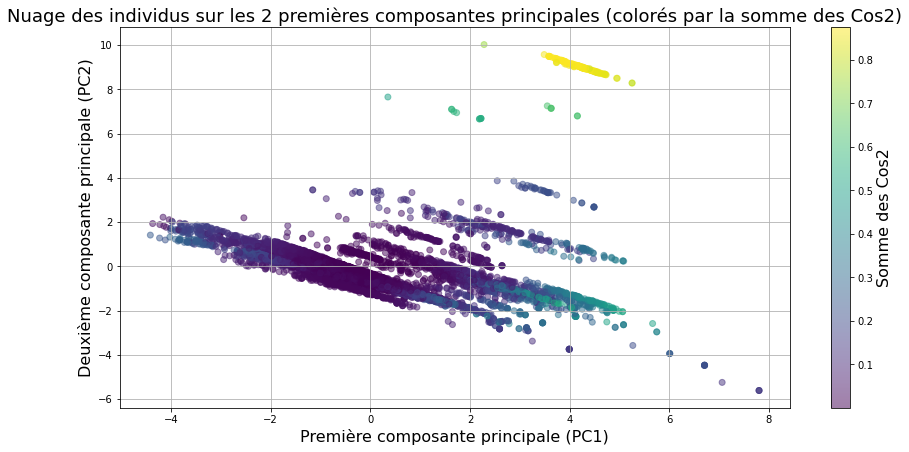

In [48]:
# Re-vérification et recalcul du cos2 pour chaque individu sur les deux premières composantes
import numpy as np
cos2_individuals = np.square(data_2d) / np.sum(np.square(data_scaled), axis=1, keepdims=True)

# Ajout du cos2 (pour les deux composantes) au DataFrame
df_2d['Cos2_PC1'] = cos2_individuals[:, 0]  # Cos2 pour la première composante
df_2d['Cos2_PC2'] = cos2_individuals[:, 1]  # Cos2 pour la deuxième composante
df_2d['Cos2_Sum'] = df_2d['Cos2_PC1'] + df_2d['Cos2_PC2']  # Somme des cos2 pour les deux composantes

# Création du graphique avec la somme des cos2 pour les deux composantes
scatter = plt.scatter(df_2d['PC1'], df_2d['PC2'], c=df_2d['Cos2_Sum'], cmap='viridis', alpha=0.5)
plt.title('Nuage des individus sur les 2 premières composantes principales (colorés par la somme des Cos2)')
plt.xlabel('Première composante principale (PC1)')
plt.ylabel('Deuxième composante principale (PC2)')
plt.colorbar(scatter, label='Somme des Cos2')
plt.grid(True)
plt.show()

Points avec un Cosinus Carré Élevé (proche de 1): Les points colorés dans des teintes plus chaudes (jaune) ont un cosinus carré élevé, ce qui signifie que ces individus sont bien représentés par les deux premières composantes. Cela indique que pour ces points, une grande partie de leur variance est capturée par ces composantes.

Points avec un Cosinus Carré Faible (moin de 0.5): Les points dans des teintes plus froides (bleu foncé) ont un cosinus carré faible, indiquant que ces individus ne sont pas aussi bien représentés. Pour ces points, d'autres dimensions au-delà des deux premières composantes principales seraient nécessaires pour capturer une plus grande partie de leur variance.

Ici, la pluparts des points avec un cosinus carré faible, donc la représentation de ces point est de mauvaise qualité.

# AFD

##
Le nombre d'axes factoriels obtenus par l'AFD est généralement égal au nombre de catégories dans votre variable cible moins un. Cela est dû à la manière dont l'AFD maximise la variance entre les groupes tout en minimisant la variance au sein des groupes.

In [56]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Creating the target variable based on the rating criteria
data.loc[data.Rating<4.1,'target']=1
data.loc[(data.Rating>=4.1) & (data.Rating<=4.4),'target']=2
data.loc[data.Rating>4.4,'target']=3


# Preparing the data for LDA
X=data.iloc[:,1:-1]
y=data.iloc[:,-1]  # Target variable
X=StandardScaler().fit_transform(X)  # Features

# Applying LDA
lda = LDA()
X_lda = lda.fit_transform(X, y)

# Number of discriminant factors
num_discriminant_factors = X_lda.shape[1]

num_discriminant_factors

2

L'AFD vise à maximiser la séparation entre les groupes définis par la variable cible. Dans votre cas, la variable cible ("target") a trois catégories (basée sur les ratings : 'low', 'medium', 'high'). Le nombre maximal d'axes discriminants est toujours le nombre de catégories dans la variable cible moins un. Ainsi, avec trois catégories, l'AFD produit au maximum 2 axes discriminants.

##
Tracer une nuage colorée selon target

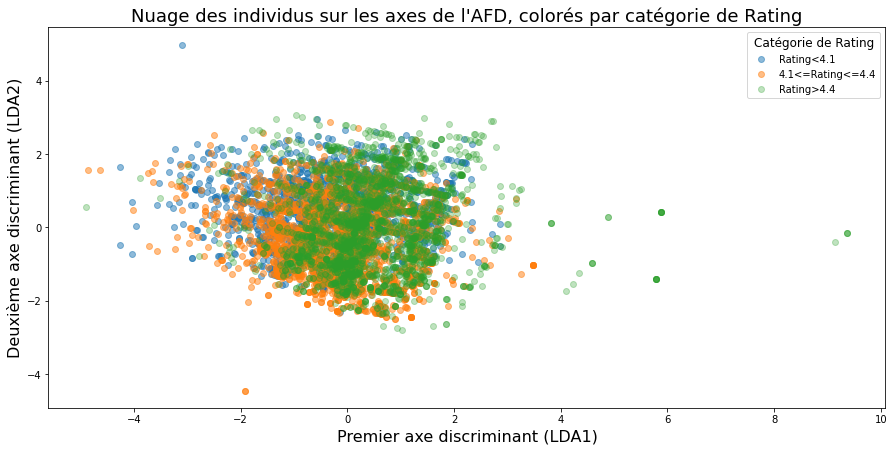

In [57]:
# Tracer le nuage des points colorés selon la variable 'target'
plt.plot(X_lda[y == 1, 0], X_lda[y == 1, 1], 'o', label='Rating<4.1', alpha=0.5)
plt.plot(X_lda[y == 2, 0], X_lda[y == 2, 1], 'o', label='4.1<=Rating<=4.4', alpha=0.5)
plt.plot(X_lda[y == 3, 0], X_lda[y == 3, 1], 'o', label='Rating>4.4',alpha=0.3) 
plt.title('Nuage des individus sur les axes de l\'AFD, colorés par catégorie de Rating')
plt.xlabel('Premier axe discriminant (LDA1)')
plt.ylabel('Deuxième axe discriminant (LDA2)')
plt.legend(title='Catégorie de Rating')
plt.show()


Interprétation du graphique :

Il semble y avoir une certaine séparation entre les trois catégories de notes, bien que cette séparation ne soit pas complètement claire. Les catégories se chevauchent dans certaines zones de l'espace de l'AFD.

Certains groupes semblent mieux séparés que d'autres. Par exemple, les applications avec des notes supérieures à 4.4 (en vert) semblent être relativement bien séparées des autres catégories, tandis que la distinction entre les applications ayant des notes inférieures à 4.1 et celles ayant des notes entre 4.1 et 4.4 est moins nette.

En conclusion, bien que l'AFD ait permis d'obtenir une certaine séparation entre les classes, il existe toujours un chevauchement significatif entre elles. Cela suggère que bien que les axes discriminants captent des aspects importants qui différencient les notes des applications, ils ne permettent pas une séparation parfaite. D'autres facteurs ou une approche analytique plus complexe pourraient être nécessaires pour obtenir une séparation plus nette des classes.

##
Accuracy et la matrice de confusion

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Training the LDA model
lda = LDA()
lda.fit(X_train, y_train)

# Making predictions on the test set
y_pred = lda.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(y_test, y_pred)

# Creating a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

accuracy, conf_matrix


(0.4622356495468278,
 array([[223, 275, 160],
        [194, 567, 167],
        [116, 334, 281]]))

L'accuracy (exactitude) de la méthode de classification par l'Analyse Factorielle Discriminante (AFD) est d'environ 46.22%. Cela signifie que 46.22% des prédictions faites par le modèle sur l'ensemble de test sont correctes.

La matrice de confusion est la suivante :

Première ligne (rating 'low'): 281 prédictions correctes, 116 prédictions incorrectes comme 'medium', 334 prédictions incorrectes comme 'high'.

Deuxième ligne (rating 'medium'): 160 prédictions incorrectes comme 'low', 223 prédictions correctes, 275 prédictions incorrectes comme 'high'.

Troisième ligne (rating 'high'): 167 prédictions incorrectes comme 'low', 194 prédictions incorrectes comme 'medium', 567 prédictions correctes.

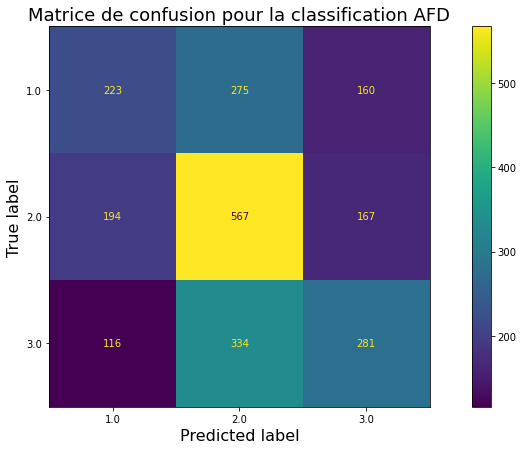

In [69]:
# Plotting the confusion matrix
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels=lda.classes_)
cm_display.plot(cmap='viridis')
plt.title('Matrice de confusion pour la classification AFD')
plt.show()


Cet accuracy n'est pas particulièrement élevé, ce qui suggère que la méthode n'est pas très efficace pour prédire les catégories de rating avec les variables actuelles. La matrice de confusion montre également un nombre significatif de prédictions incorrectes.

La matrice de confusion colorée fournit une représentation visuelle des performances de la classification AFD. Chaque cellule montre le nombre de prédictions pour chaque combinaison de classe réelle (en ligne) et prédite (en colonne). Les couleurs plus foncées indiquent un nombre plus élevé de prédictions.

Comme on peut le voir, il y a des erreurs significatives de classification dans chaque catégorie. Bien qu'il y ait un certain nombre de prédictions correctes (particulièrement pour la catégorie 'high'), les erreurs, en particulier les fausses classifications entre les catégories 'low' et 'high', sont assez élevées. Cela suggère que, bien que l'AFD puisse capter certaines tendances dans les données, elle n'est pas suffisamment précise pour être utilisée comme un outil de prédiction fiable avec ces variables dans leur forme actuelle.

In [70]:
preds = lda.predict(X)
accuracy = (preds == y).mean()
print(f'Accuracy : {accuracy:.3%}')

Accuracy : 47.999%


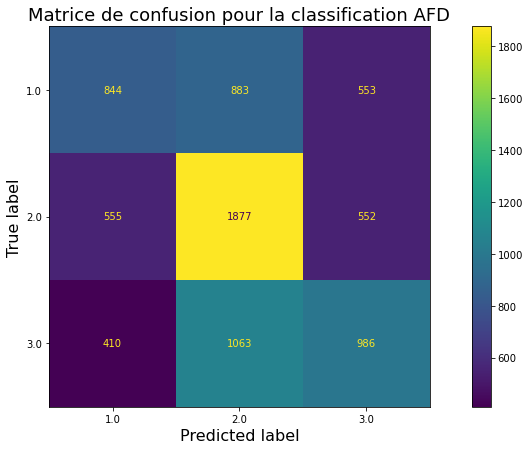

In [71]:
conf_matrix = confusion_matrix(y, preds)
cm_display = ConfusionMatrixDisplay(conf_matrix, display_labels=lda.classes_)
cm_display.plot(cmap='viridis')
plt.title('Matrice de confusion pour la classification AFD')
plt.show()

Si on applique directement et sans utiliser la méthode de train_test_split, la résultat de accuracy est presque la même, mais nombres de prédiction dans la matrice de confusion sont plus grands que l'avant.

En conclusion, bien que l'AFD ait pu identifier des axes discriminants, la précision globale de la classification n'est pas très élevée, et il y a un nombre significatif d'erreurs de classification. Cela peut être dû à la complexité des données, à l'overlap entre les classes de Ratings, ou à la nécessité d'utiliser des méthodes de classification plus sophistiquées et possiblement d'autres variables explicatives pour améliorer la performance de la classificatio

# SVM

##
Entraîner une SVM linéaire (LinearSVR) pour prédire Rating, en utilisant toutes les données.

In [72]:
from sklearn.svm import LinearSVR

# Préparer les caractéristiques (features) et la cible (target)
X_svm = data_scaled  # Caractéristiques déjà normalisées
y_svm = data['Rating']

# Créer et entraîner le modèle LinearSVR
svm_model = LinearSVR(dual= True,random_state=42, max_iter=1000000)
svm_model.fit(X_svm, y_svm)

# Afficher les paramètres du modèle entraîné pour confirmation
svm_model.get_params()


{'C': 1.0,
 'dual': True,
 'epsilon': 0.0,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'loss': 'epsilon_insensitive',
 'max_iter': 1000000,
 'random_state': 42,
 'tol': 0.0001,
 'verbose': 0}

##
Calculer la corrélation entre prédiction et vraie valeur, et tracer le scatterplot qui les compare.

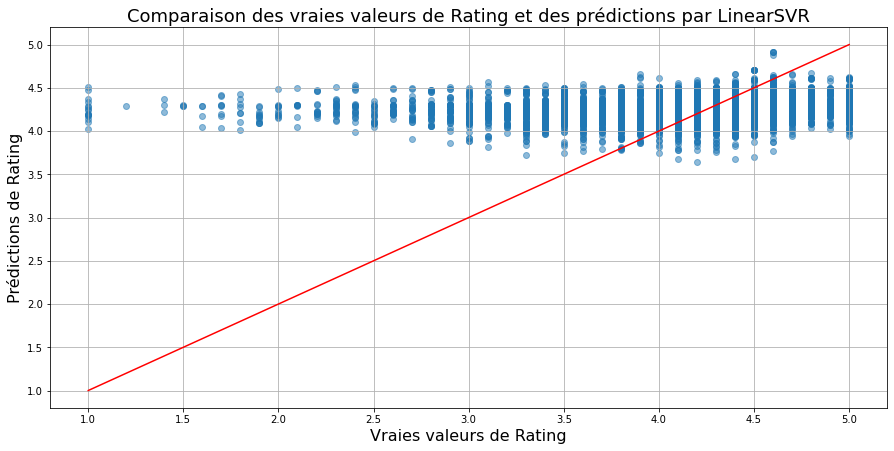

0.22132817042692438

In [74]:
# Générer les prédictions du modèle
y_pred_svm = svm_model.predict(X_svm)

# Calculer la corrélation entre les prédictions et les vraies valeurs
correlation = np.corrcoef(y_svm, y_pred_svm)[0, 1]

# Tracer le scatterplot comparant les prédictions et les vraies valeurs
plt.scatter(y_svm, y_pred_svm, alpha=0.5)
plt.xlabel('Vraies valeurs de Rating')
plt.ylabel('Prédictions de Rating')
plt.title('Comparaison des vraies valeurs de Rating et des prédictions par LinearSVR')
plt.plot([min(y_svm), max(y_svm)], [min(y_svm), max(y_svm)], color='red')  # ligne y=x pour référence
plt.grid(True)
plt.show()

correlation


La corrélation entre les prédictions du modèle LinearSVR et les vraies valeurs de Rating est d'environ 0.22. Cette corrélation, bien que positive, est relativement faible, indiquant que la relation entre les prédictions du modèle et les vraies valeurs de Rating n'est pas très forte.

Le scatterplot montre également cette relation. Les points sont dispersés autour de la ligne rouge (qui représente une correspondance parfaite entre les prédictions et les vraies valeurs). Une dispersion importante autour de cette ligne indique une précision limitée dans les prédictions du modèle.

En conclusion, le modèle LinearSVR semble avoir une capacité limitée à prédire avec précision les Ratings des applications sur le Google Play Store dans cet ensemble de données. Cela peut être dû à la complexité des facteurs influençant les Ratings, ou à la nécessité d'utiliser un modèle plus sophistiqué ou d'ajuster davantage les paramètres du modèle actuel.

##
Répéter l’entraînement en utilisant, cette fois, une SVM non-linéaire (par exemple, noyau
rbf) sur toutes les données.

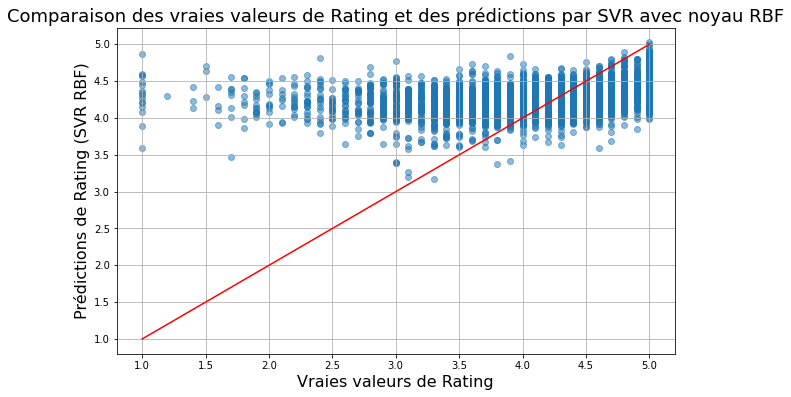

0.3427732984284853

In [75]:
from sklearn.svm import SVR

# Créer et entraîner le modèle SVR avec noyau RBF
svm_rbf_model = SVR(kernel='rbf')
svm_rbf_model.fit(X_svm, y_svm)

# Générer les prédictions du modèle SVR avec noyau RBF
y_pred_svm_rbf = svm_rbf_model.predict(X_svm)

# Calculer la corrélation entre les prédictions et les vraies valeurs pour le modèle SVR avec noyau RBF
correlation_rbf = np.corrcoef(y_svm, y_pred_svm_rbf)[0, 1]

# Tracer le scatterplot comparant les prédictions et les vraies valeurs pour le modèle SVR avec noyau RBF
plt.figure(figsize=(10, 6))
plt.scatter(y_svm, y_pred_svm_rbf, alpha=0.5)
plt.xlabel('Vraies valeurs de Rating')
plt.ylabel('Prédictions de Rating (SVR RBF)')
plt.title('Comparaison des vraies valeurs de Rating et des prédictions par SVR avec noyau RBF')
plt.plot([min(y_svm), max(y_svm)], [min(y_svm), max(y_svm)], color='red')  # ligne y=x pour référence
plt.grid(True)
plt.show()

correlation_rbf


 le modèle SVM avec noyau RBF semble offrir une meilleure prédiction des Ratings par rapport à la SVM linéaire dans cet ensemble de données. Néanmoins, il y a encore une marge d'amélioration, et d'autres techniques ou paramétrisations pourraient être explorées pour améliorer davantage la précision des prédictions. 

# Réseaux de neurones

##
Entraîner un réseau de neurones (MLPRegressor) avec les paramètres standards.

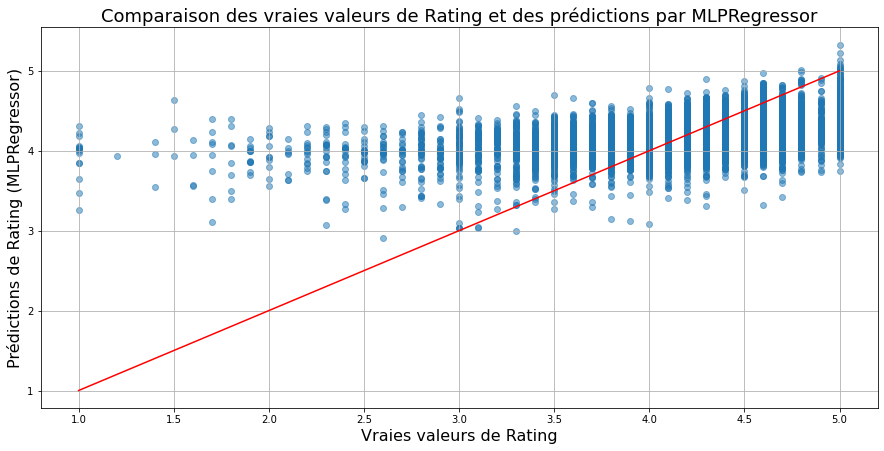

0.4501270381953857

In [77]:
from sklearn.neural_network import MLPRegressor

# Créer et entraîner le modèle MLPRegressor avec les paramètres par défaut
mlp_model = MLPRegressor(random_state=42)
mlp_model.fit(X_svm, y_svm)

# Générer les prédictions du modèle MLPRegressor
y_pred_mlp = mlp_model.predict(X_svm)

# Calculer la corrélation entre les prédictions et les vraies valeurs pour le modèle MLPRegressor
correlation_mlp = np.corrcoef(y_svm, y_pred_mlp)[0, 1]

# Tracer le scatterplot comparant les prédictions et les vraies valeurs pour le modèle MLPRegressor
plt.scatter(y_svm, y_pred_mlp, alpha=0.5)
plt.xlabel('Vraies valeurs de Rating')
plt.ylabel('Prédictions de Rating (MLPRegressor)')
plt.title('Comparaison des vraies valeurs de Rating et des prédictions par MLPRegressor')
plt.plot([min(y_svm), max(y_svm)], [min(y_svm), max(y_svm)], color='red')  # ligne y=x pour référence
plt.grid(True)
plt.show()

correlation_mlp



La corrélation entre les prédictions du modèle MLPRegressor (réseau de neurones) et les vraies valeurs de Rating est d'environ 0.450. Cette valeur est supérieure à celle obtenue avec les modèles SVM linéaire (0.221) et SVM avec noyau RBF (0.343), indiquant une amélioration dans la capacité du modèle à prédire les Ratings.

En conclusion, sur la base de la corrélation entre les prédictions et les vraies valeurs, le modèle MLPRegressor semble offrir de meilleures performances pour prédire les Ratings des applications sur le Google Play Store par rapport aux modèles SVM linéaire et SVM avec noyau RBF dans cet ensemble de données. Cela suggère que le réseau de neurones est capable de capturer des relations plus complexes et non linéaires dans les données. Néanmoins, il reste encore une marge d'amélioration, et des ajustements supplémentaires des paramètres ou une exploration de modèles plus complexes pourraient être envisagés pour améliorer davantage les prédictions. 

##
Séparer le jeu de données en 80% d’entraînement et 20% de test. Répéter l’entraînement de AFD, SVM (linéaire et non) et les deux réseaux de neurones, en n’entraînant que sur le premier 80% et évaluant sur le reste.

In [78]:
from sklearn.model_selection import train_test_split

# Utilisez features_normalized pour les modèles de régression et 'data' pour l'AFD
X_train, X_test, y_train, y_test = train_test_split(data_scaled, y_svm, test_size=0.2, random_state=42)
X_train_afd, X_test_afd, y_train_afd, y_test_afd = train_test_split(data, data['target'], test_size=0.2, random_state=42)

In [79]:
from sklearn.metrics import mean_squared_error, r2_score

def train_evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
   
    correlation = np.corrcoef(y_test, y_pred)[0, 1]
    return  correlation

In [80]:
# SVM Linéaire
svm_linear_test = LinearSVR(max_iter=1000000, random_state=42)
correlation_svm_linear_test = train_evaluate_model(svm_linear_test, X_train, y_train, X_test, y_test)

# SVM Non-linéaire (RBF)
svm_rbf_test = SVR(kernel='rbf')
correlation_svm_rbf_test = train_evaluate_model(svm_rbf_test, X_train, y_train, X_test, y_test)

# MLPRegressor avec paramètres par défaut
mlp_test = MLPRegressor(random_state=42)
correlation_mlp_test = train_evaluate_model(mlp_test, X_train, y_train, X_test, y_test)

correlation_svm_linear_test, correlation_svm_rbf_test, correlation_mlp_test

(0.19959293200690528, 0.2607454286910541, 0.326216722983077)

 les corrélations entre les prédictions et les vraies valeurs de Rating sur l'ensemble de test pour les trois modèles :

SVM Linéaire : Corrélation d'environ 0.199
SVM Non-linéaire (RBF) : Corrélation d'environ 0.261
MLPRegressor : Corrélation d'environ 0.326
Ces résultats montrent une certaine diminution de la corrélation par rapport aux évaluations précédentes, qui étaient basées sur l'ensemble des données (entraînement et test combinés). Cette baisse est attendue, car il est plus difficile pour les modèles de généraliser à des données non vues (ensemble de test) qu'aux données sur lesquelles ils ont été entraînés.

En comparant les trois modèles, le MLPRegressor (réseau de neurones) continue d'avoir la corrélation la plus élevée, suggérant qu'il est le plus performant des trois pour prédire les Ratings dans cet ensemble de données. Le modèle SVM avec noyau RBF a une performance légèrement meilleure que le modèle SVM linéaire, ce qui est cohérent avec la capacité des modèles non linéaires à capturer des relations plus complexes dans les données.

En conclusion, bien que les performances globales soient modérées, le MLPRegressor semble être le modèle le plus prometteur parmi ceux testés pour cette tâche de prédiction